In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import time

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [3]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [4]:
# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("After normalization:")
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

print("Label shape:", y_train.shape)

After normalization:
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Label shape: (50000, 10)


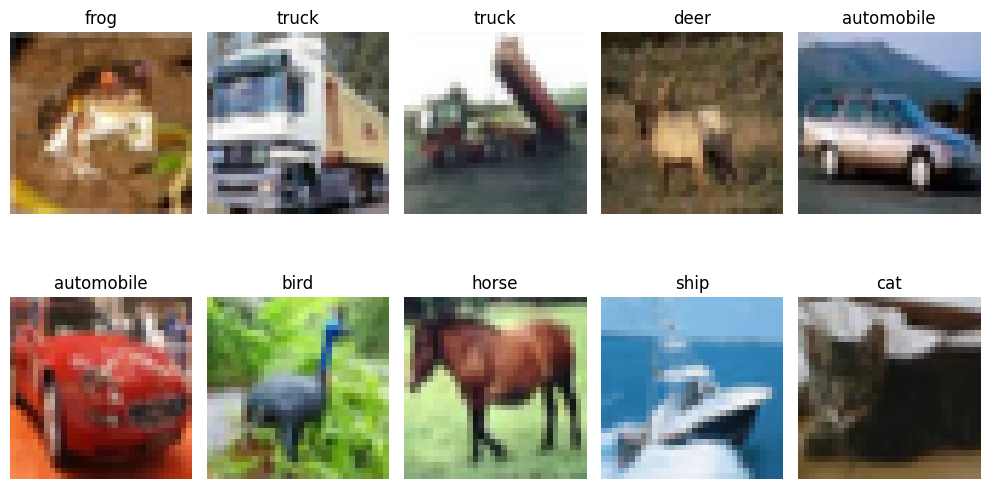

In [5]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
ann_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Flatten(),

    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),

    layers.Dense(10, activation="softmax")
])

ann_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
start_time = time.time()

ann_history = ann_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

ann_training_time = time.time() - start_time

print(f"\nANN Training Time: {ann_training_time:.2f} seconds")

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3863 - loss: 1.7049 - val_accuracy: 0.3904 - val_loss: 1.6985
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 51ms/step - accuracy: 0.4210 - loss: 1.6125 - val_accuracy: 0.4044 - val_loss: 1.6536
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.4421 - loss: 1.5551 - val_accuracy: 0.4480 - val_loss: 1.5494
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.4599 - loss: 1.5063 - val_accuracy: 0.4538 - val_loss: 1.5243
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.4749 - loss: 1.4718 - val_accuracy: 0.4564 - val_loss: 1.5114

ANN Training Time: 190.32 seconds


In [9]:
ann_test_loss, ann_test_accuracy = ann_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("ANN Test Loss:", ann_test_loss)
print("ANN Test Accuracy:", ann_test_accuracy)

ANN Test Loss: 1.5086838006973267
ANN Test Accuracy: 0.45419999957084656


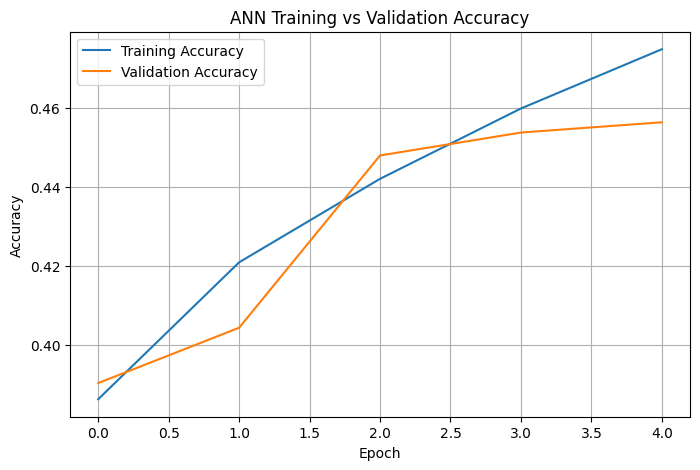

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    ann_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    ann_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ANN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

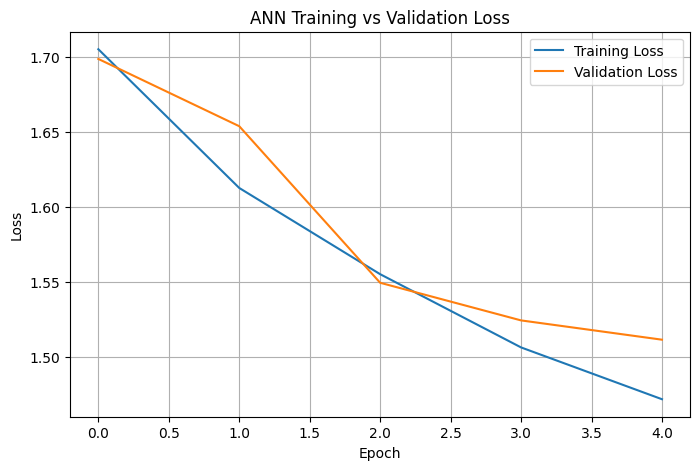

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    ann_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    ann_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
ann_predictions = ann_model.predict(x_test)

ann_pred_classes = np.argmax(ann_predictions, axis=1)
ann_true_classes = np.argmax(y_test, axis=1)

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predictions generated successfully.


In [13]:
ann_precision = precision_score(
    ann_true_classes,
    ann_pred_classes,
    average="weighted"
)

ann_recall = recall_score(
    ann_true_classes,
    ann_pred_classes,
    average="weighted"
)

ann_f1 = f1_score(
    ann_true_classes,
    ann_pred_classes,
    average="weighted"
)

print("ANN Precision:", ann_precision)
print("ANN Recall:", ann_recall)
print("ANN F1 Score:", ann_f1)

ANN Precision: 0.4728209774418485
ANN Recall: 0.4542
ANN F1 Score: 0.45415171560179507


In [14]:
print(
    classification_report(
        ann_true_classes,
        ann_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.53      0.51      0.52      1000
  automobile       0.64      0.50      0.56      1000
        bird       0.35      0.32      0.33      1000
         cat       0.29      0.33      0.31      1000
        deer       0.47      0.30      0.36      1000
         dog       0.32      0.48      0.38      1000
        frog       0.49      0.48      0.48      1000
       horse       0.62      0.41      0.50      1000
        ship       0.47      0.72      0.57      1000
       truck       0.55      0.50      0.52      1000

    accuracy                           0.45     10000
   macro avg       0.47      0.45      0.45     10000
weighted avg       0.47      0.45      0.45     10000



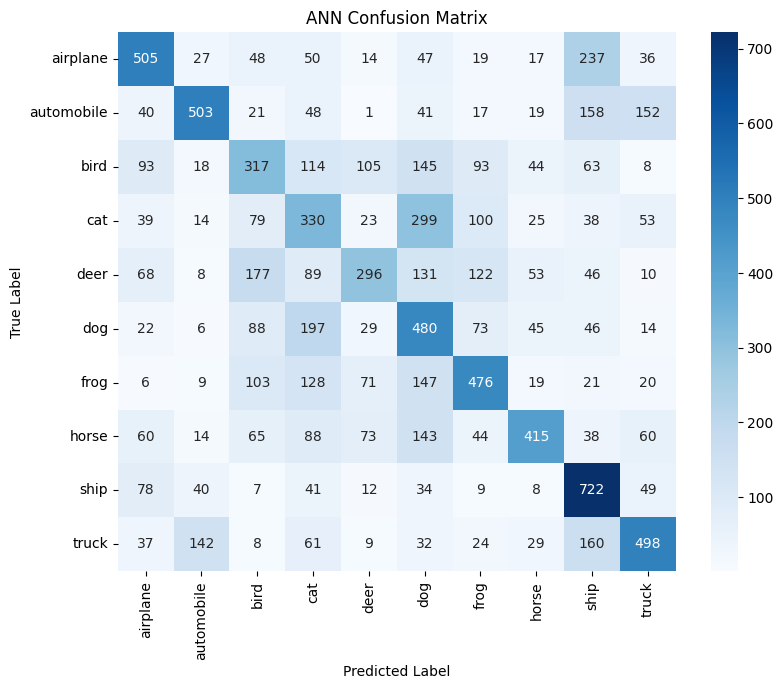

In [15]:
ann_cm = confusion_matrix(
    ann_true_classes,
    ann_pred_classes
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    ann_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [16]:
cnn_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # First convolutional layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional layer
    layers.Conv2D(
        64,
        (5, 5),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional layer
    layers.Conv2D(
        128,
        (7, 7),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 717,258 (2.74 MB)

 Trainable params: 717,258 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
start_time = time.time()

cnn_history = cnn_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

cnn_training_time = time.time() - start_time

print(f"\nCNN Training Time: {cnn_training_time:.2f} seconds")

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 319s 453ms/step - accuracy: 0.4183 - loss: 1.5964 - val_accuracy: 0.5718 - val_loss: 1.1907
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 321s 452ms/step - accuracy: 0.5900 - loss: 1.1703 - val_accuracy: 0.6556 - val_loss: 0.9788
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 319s 448ms/step - accuracy: 0.6637 - loss: 0.9733 - val_accuracy: 0.6928 - val_loss: 0.8775
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 315s 447ms/step - accuracy: 0.7109 - loss: 0.8442 - val_accuracy: 0.7382 - val_loss: 0.7775
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 318s 441ms/step - accuracy: 0.7470 - loss: 0.7351 - val_accuracy: 0.7336 - val_loss: 0.7808

CNN Training Time: 1595.21 seconds


In [19]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_accuracy)

CNN Test Loss: 0.8232614398002625
CNN Test Accuracy: 0.7195000052452087


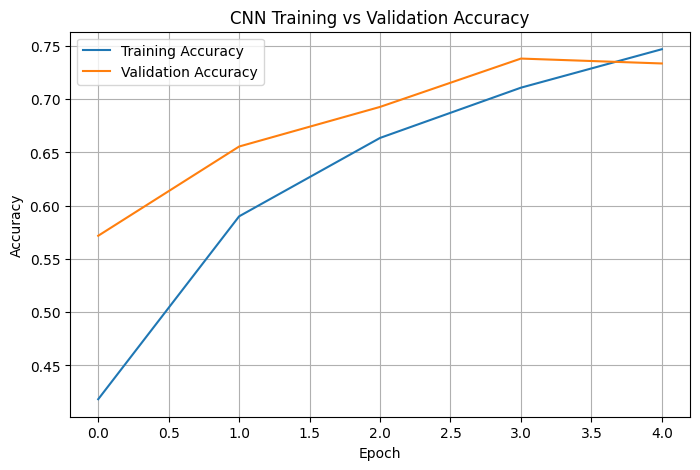

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

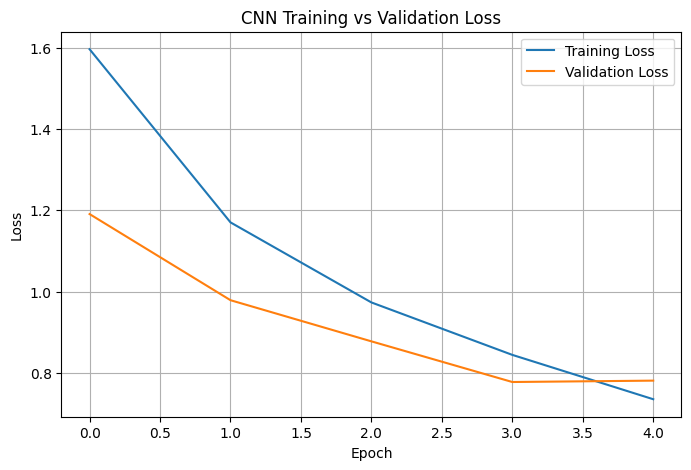

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
cnn_predictions = cnn_model.predict(x_test)

cnn_pred_classes = np.argmax(cnn_predictions, axis=1)
cnn_true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step


In [23]:
cnn_precision = precision_score(
    cnn_true_classes,
    cnn_pred_classes,
    average="weighted"
)

cnn_recall = recall_score(
    cnn_true_classes,
    cnn_pred_classes,
    average="weighted"
)

cnn_f1 = f1_score(
    cnn_true_classes,
    cnn_pred_classes,
    average="weighted"
)

print("CNN Precision:", cnn_precision)
print("CNN Recall:", cnn_recall)
print("CNN F1 Score:", cnn_f1)

CNN Precision: 0.7270092170848796
CNN Recall: 0.7195
CNN F1 Score: 0.7205068805874937


In [24]:
print(
    classification_report(
        cnn_true_classes,
        cnn_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.78      0.74      0.76      1000
  automobile       0.83      0.87      0.85      1000
        bird       0.69      0.56      0.62      1000
         cat       0.50      0.55      0.52      1000
        deer       0.72      0.60      0.66      1000
         dog       0.53      0.70      0.61      1000
        frog       0.81      0.76      0.78      1000
       horse       0.77      0.77      0.77      1000
        ship       0.85      0.81      0.83      1000
       truck       0.79      0.83      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.72      0.72     10000



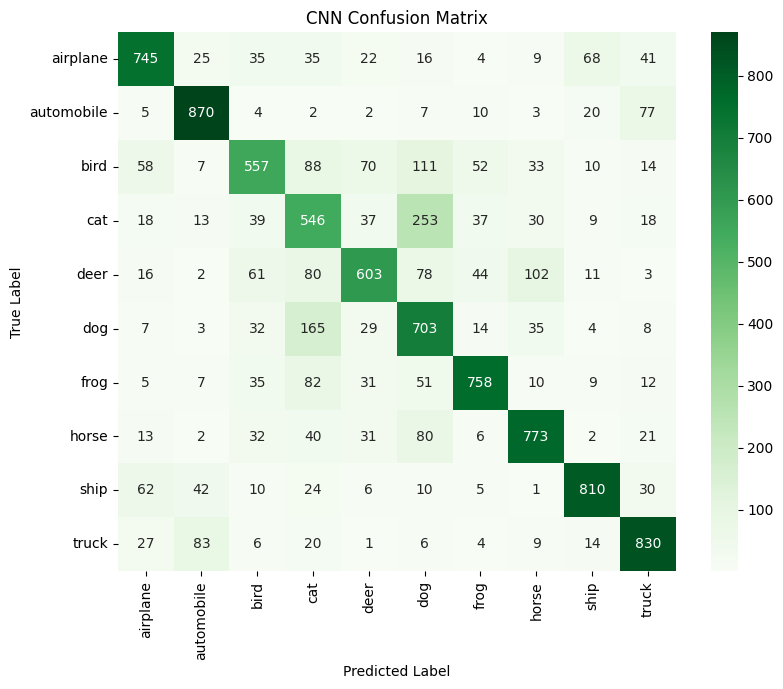

In [25]:
cnn_cm = confusion_matrix(
    cnn_true_classes,
    cnn_pred_classes
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [26]:
misclassified_indices = np.where(
    cnn_pred_classes != cnn_true_classes
)[0]

print(
    "Total misclassified samples:",
    len(misclassified_indices)
)

Total misclassified samples: 2805


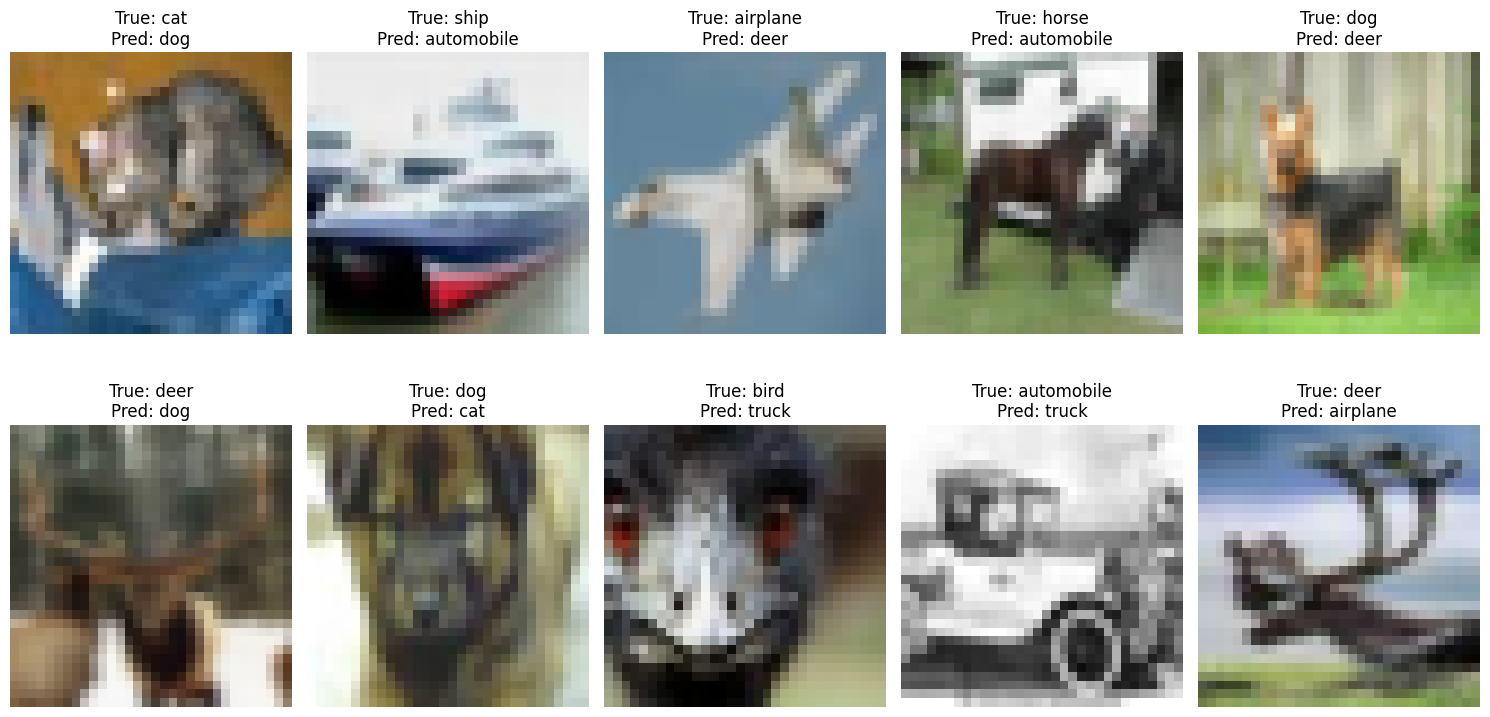

In [27]:
plt.figure(figsize=(15, 8))

for i, index in enumerate(misclassified_indices[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[index])

    true_label = class_names[cnn_true_classes[index]]
    predicted_label = class_names[cnn_pred_classes[index]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
ann_parameters = ann_model.count_params()
cnn_parameters = cnn_model.count_params()

print("ANN Parameters:", ann_parameters)
print("CNN Parameters:", cnn_parameters)
print("ANN SUMMARY")
ann_model.summary()

print("\nCNN SUMMARY")
cnn_model.summary()

ANN Parameters: 1738890
CNN Parameters: 717258
ANN SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,216,672 (19.90 MB)

 Trainable params: 1,738,890 (6.63 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,151,776 (8.21 MB)

 Trainable params: 717,258 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,434,518 (5.47 MB)

In [29]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Parameters": [
        ann_parameters,
        cnn_parameters
    ],
    "Test Accuracy": [
        ann_test_accuracy,
        cnn_test_accuracy
    ],
    "Test Loss": [
        ann_test_loss,
        cnn_test_loss
    ],
    "Precision": [
        ann_precision,
        cnn_precision
    ],
    "Recall": [
        ann_recall,
        cnn_recall
    ],
    "F1 Score": [
        ann_f1,
        cnn_f1
    ],
    "Training Time (sec)": [
        ann_training_time,
        cnn_training_time
    ]
})

comparison

,Model,Parameters,Test Accuracy,Test Loss,Precision,Recall,F1 Score,Training Time (sec)
0,ANN,1738890,0.4542,1.508684,0.472821,0.4542,0.454152,190.323563
1,CNN,717258,0.7195,0.823261,0.727009,0.7195,0.720507,1595.209565


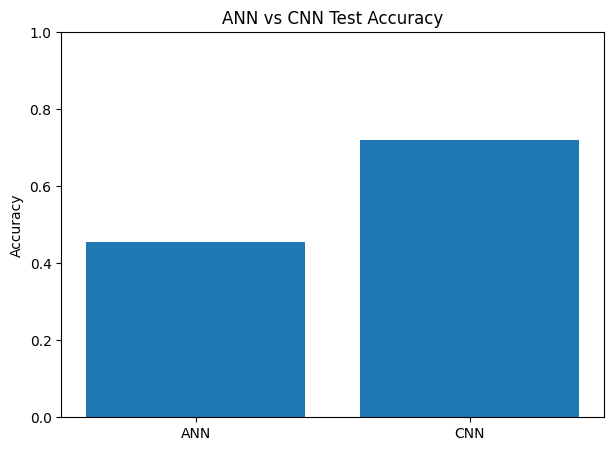

In [30]:
models = ["ANN", "CNN"]

accuracies = [
    ann_test_accuracy,
    cnn_test_accuracy
]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.title("ANN vs CNN Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

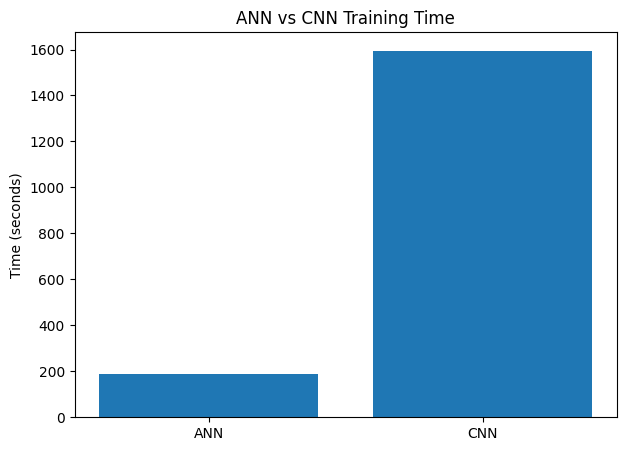

In [31]:
training_times = [
    ann_training_time,
    cnn_training_time
]

plt.figure(figsize=(7, 5))

plt.bar(models, training_times)

plt.title("ANN vs CNN Training Time")
plt.ylabel("Time (seconds)")

plt.show()

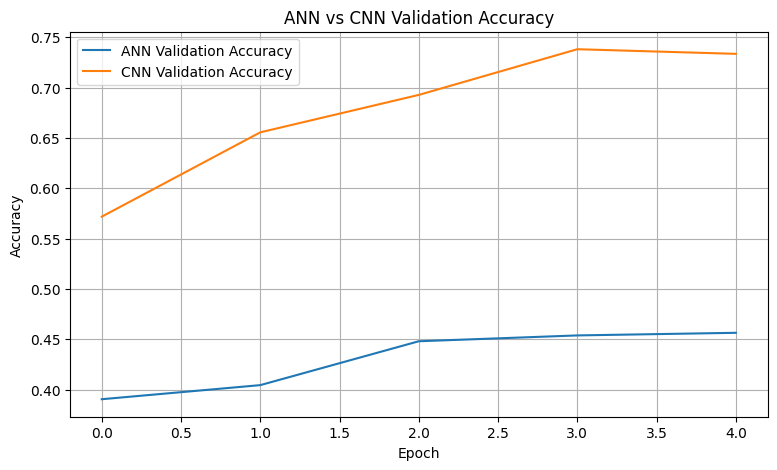

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(
    ann_history.history["val_accuracy"],
    label="ANN Validation Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="CNN Validation Accuracy"
)

plt.title("ANN vs CNN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
ann_model.save("cifar10_ann_model.keras")
cnn_model.save("cifar10_cnn_model.keras")

print("Models saved successfully.")

Models saved successfully.
